In [1]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

In [2]:
import tensorflow as tf
from tensorflow import keras

2026-04-25 08:28:21.523167: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

### Dataset Characteristics:
Number of instances: 20640
Number of attributes: 8 numeric, predictive attributes and the target
Target: Median house value for California districts, expressed in hundreds of thousands of dollars ($100,000).
### Attribute Information:
1. MedInc: median income in block group
2. HouseAge: median house age in block group
3. AveRooms: average number of rooms per household
4. AveBedrms: average number of bedrooms per household
5. Population: block group population
6. AveOccup: average number of household members
7. Latitude: block group latitude
8. Longitude: block group longitude
##### Missing Attribute Values: None
Documentation: https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset


In [4]:
print(housing.feature_names)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [5]:
from sklearn.model_selection import train_test_split
X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data, housing.target)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, test_size=0.25, random_state=42)

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

In [7]:
np.random.seed(42)
tf.random.set_seed(42)

In [8]:
X_train.shape

(11610, 8)

In [9]:
model = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=[8]),
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(1)
])
# keras.layers.Dense(30, activation="relu", input_shape=X_train.shape[1:]),
model.summary()

/opt/miniconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           270 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,231 (4.81 KB)

 Trainable params: 1,231 (4.81 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(loss="mean_squared_error", 
                optimizer=keras.optimizers.SGD(learning_rate=1e-3),
              metrics=["mae"]) # mean_absolute_error

In [11]:
model_history = model.fit(X_train, y_train, epochs=20, validation_data=(X_valid, y_valid))

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 2.7961 - mae: 1.2755 - val_loss: 0.7143 - val_mae: 0.6266
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7139 - mae: 0.6201 - val_loss: 0.6327 - val_mae: 0.5976
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6470 - mae: 0.5942 - val_loss: 0.5970 - val_mae: 0.5803
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6131 - mae: 0.5774 - val_loss: 0.5694 - val_mae: 0.5661
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.5870 - mae: 0.5639 - val_loss: 0.5466 - val_mae: 0.5542
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.5653 - mae: 0.5527 - val_loss: 0.5272 - val_mae: 0.5438
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.5469 - mae: 0.5430 - val_loss: 0.5106 - val_mae: 0.5348
Epoch 8/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5317 - mae: 0.5345 - val_loss: 0.4964 - val_mae: 0.5267
Epoch 9/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - l

In [12]:
mae_test = model.evaluate(X_test, y_test)
print("MAE on test set:", mae_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4743 - mae: 0.4998
MAE on test set: [0.4614282548427582, 0.4890481233596802]


In [13]:
model_history.history

{'loss': [1.8668513298034668,
  0.7172849774360657,
  0.6608434319496155,
  0.6268137693405151,
  0.600490152835846,
  0.5789639353752136,
  0.5608108639717102,
  0.5454715490341187,
  0.5327000617980957,
  0.5217714309692383,
  0.512521505355835,
  0.5046712756156921,
  0.49797895550727844,
  0.492123544216156,
  0.4869310259819031,
  0.4822494387626648,
  0.4780648648738861,
  0.4742734730243683,
  0.4707799553871155,
  0.46753278374671936],
 'mae': [0.9703185558319092,
  0.6203716993331909,
  0.5969729423522949,
  0.5805834531784058,
  0.5673971772193909,
  0.5562236905097961,
  0.5464480519294739,
  0.5380600094795227,
  0.5310117602348328,
  0.5247988700866699,
  0.5194281935691833,
  0.51479172706604,
  0.5108094811439514,
  0.5072586536407471,
  0.5041795969009399,
  0.5012409090995789,
  0.4986572861671448,
  0.4962689280509949,
  0.4940184950828552,
  0.4919207692146301],
 'val_loss': [0.7142751812934875,
  0.6326904892921448,
  0.596966028213501,
  0.5693620443344116,
  0.546

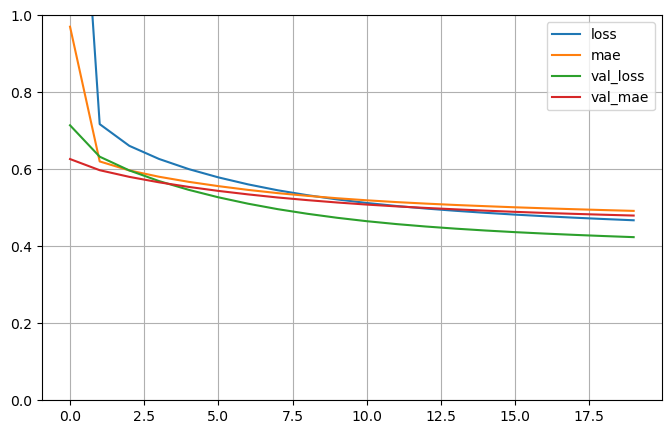

In [14]:
pd.DataFrame(model_history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

In [15]:
X_new = X_test[:3]
y_pred = model.predict(X_new)
print("Predictions:\n", y_pred)
print("Actual values:\n", y_test[:3])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Predictions:
 [[2.590286 ]
 [2.6637144]
 [2.8025253]]
Actual values:
 [2.544 1.873 3.4  ]


### Functional API

In [16]:
del model # deletes the model to free up memory

In [17]:
keras.backend.clear_session() # This is useful to avoid clutter from old models and layers, especially when memory is limited.

### Functional API
Not all models are simple stacks of layers. The functional API lets you build complex models, such as multi-output models, directed acyclic graphs, or models with shared layers.

In [18]:
input_ = keras.layers.Input(shape=X_train.shape[1:])
hidden1 = keras.layers.Dense(30, activation="relu")(input_)
hidden2 = keras.layers.Dense(30, activation="relu")(hidden1)
concat = keras.layers.Concatenate()([input_, hidden2])
output = keras.layers.Dense(1)(concat)
model = keras.models.Model(inputs=[input_], outputs=[output])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30)        │        270 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 30)        │        930 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 38)        │          0 │ input_layer[0][0… │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         39 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,239 (4.84 KB)

 Trainable params: 1,239 (4.84 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(loss="mean_squared_error", 
                optimizer=keras.optimizers.SGD(learning_rate=1e-3),
              metrics=["mae"]) # mean_absolute_error

In [20]:
model_history = model.fit(X_train, y_train, epochs=40, validation_data=(X_valid, y_valid))

Epoch 1/40


/opt/miniconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor']. Received: the structure of inputs=*
  warnings.warn(


363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3.8006 - mae: 1.5026 - val_loss: 0.9377 - val_mae: 0.7290
Epoch 2/40
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8760 - mae: 0.6991 - val_loss: 0.7285 - val_mae: 0.6479
Epoch 3/40
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7243 - mae: 0.6316 - val_loss: 0.6525 - val_mae: 0.6057
Epoch 4/40
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6555 - mae: 0.5961 - val_loss: 0.6074 - val_mae: 0.5833
Epoch 5/40
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6177 - mae: 0.5771 - val_loss: 0.5732 - val_mae: 0.5644
Epoch 6/40
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5876 - mae: 0.5615 - val_loss: 0.5483 - val_mae: 0.5520
Epoch 7/40
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5659 - mae: 0.5503 - val_loss: 0.5281 - val_mae: 0.5410
Epoch 8/40
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5481 - mae: 0.5409 - val_loss: 0.5124 - val_mae: 0.5326
Epoch 9/40
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5353 

In [21]:
mae_test = model.evaluate(X_test, y_test)
print("MAE on test set:", mae_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4457 - mae: 0.4774
MAE on test set: [0.43384218215942383, 0.46800172328948975]


In [22]:
model_history.history

{'loss': [2.5178606510162354,
  0.8723292946815491,
  0.733833909034729,
  0.6716295480728149,
  0.6297818422317505,
  0.6021795868873596,
  0.5798492431640625,
  0.5632925629615784,
  0.5494781136512756,
  0.5385008454322815,
  0.5292080640792847,
  0.5214270353317261,
  0.5145902037620544,
  0.5085407495498657,
  0.5030466914176941,
  0.4980933964252472,
  0.4935472011566162,
  0.48938482999801636,
  0.4854913055896759,
  0.4817904233932495,
  0.4783499538898468,
  0.47502022981643677,
  0.4718983471393585,
  0.4689226448535919,
  0.46609213948249817,
  0.46334657073020935,
  0.46073102951049805,
  0.4582083523273468,
  0.4557705223560333,
  0.45342835783958435,
  0.4511147737503052,
  0.44888877868652344,
  0.44670113921165466,
  0.44460174441337585,
  0.4425404369831085,
  0.44052043557167053,
  0.4385383129119873,
  0.4365820586681366,
  0.43465906381607056,
  0.4328215718269348],
 'mae': [1.1284998655319214,
  0.6894382834434509,
  0.629361629486084,
  0.6008841395378113,
  0.579

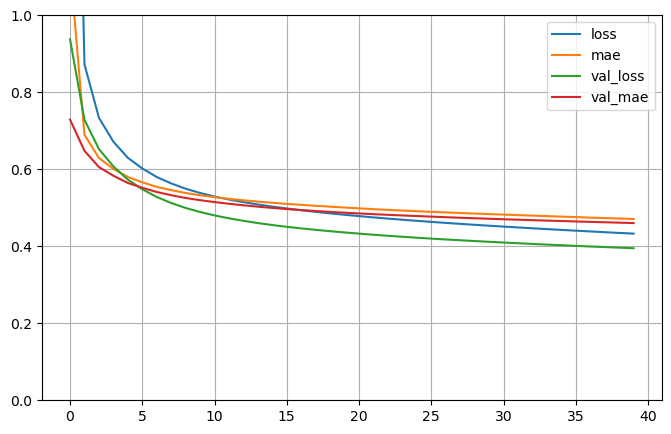

In [23]:
pd.DataFrame(model_history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

## Saving and Restoring Models

In [24]:
model.save("my_Func_model.h5") # Legacy way to save Keras models, using the HDF5 format. It is still supported but the native Keras format is now recommended.
#model.save("my_Func_model.keras") # New way to save Keras models, using the native Keras format. It is recommended over the older HDF5 format.
# Only save a model after training it, otherwise you will just save the untrained model. You can load the model later and use it to make predictions without having to retrain it.

In [25]:
%pwd

'/Users/malvern/development/ML/machine-learning-python-r'

In [26]:
del model
keras.backend.clear_session()

In [27]:
#model = keras.models.load_model("my_Func_model.h5") # Load the model saved in HDF5 format. If you saved it in the newer Keras format, use "my_Func_model.keras" instead.
model = keras.models.load_model("my_Func_model.keras") # Load the model saved in the newer Keras format. If you saved it in the older HDF5 format, use "my_Func_model.h5" instead.
model.summary()

/opt/miniconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:719: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 8 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30)        │        270 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 30)        │        930 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 38)        │          0 │ input_layer[0][0… │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         39 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,480 (9.69 KB)

 Trainable params: 1,239 (4.84 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,241 (4.85 KB)

In [28]:
y_pred = model.predict(X_new)
print("Predictions:\n", y_pred)
print("Actual values:\n", y_test[:3])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
Predictions:
 [[2.2362177]
 [2.617401 ]
 [2.583399 ]]
Actual values:
 [2.544 1.873 3.4  ]


### Using Callbacks during Training

In [29]:
del model
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [30]:
model = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=X_train.shape[1:]),
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(1)
])
model.summary()

/opt/miniconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           270 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,231 (4.81 KB)

 Trainable params: 1,231 (4.81 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
model.compile(loss="mean_squared_error", optimizer=keras.optimizers.SGD(learning_rate=1e-3))

In [32]:
checkpoint_cb = keras.callbacks.ModelCheckpoint("Model-{epoch:02d}.keras", save_best_only=True)

In [33]:
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_valid, y_valid), callbacks=[checkpoint_cb])

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.2605 - val_loss: 0.8554
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8060 - val_loss: 0.6487
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6549 - val_loss: 0.5972
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6126 - val_loss: 0.5665
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5860 - val_loss: 0.5423
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5649 - val_loss: 0.5221
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5476 - val_loss: 0.5052
Epoch 8/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5332 - val_loss: 0.4912
Epoch 9/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5212 - val_loss: 0.4796
Epoch 10/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5113 - val_loss: 0.4700
Epoch 11/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5030 - val_loss: 0.4618
Epoch 12/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

In [34]:
del model
keras.backend.clear_session()

In [35]:
model = keras.models.load_model("Model-20.keras") # Load the model saved in HDF5 format. If you saved it in the newer Keras format, use "my_Func_model.keras" instead.
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           270 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,233 (4.82 KB)

 Trainable params: 1,231 (4.81 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [36]:
mse_test = model.evaluate(X_test, y_test)
print("MSE on test set:", mse_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4802
MSE on test set: 0.46584591269493103


### Best Model Only

In [37]:
del model
keras.backend.clear_session()

In [38]:
model = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=X_train.shape[1:]),
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(1)
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           270 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,231 (4.81 KB)

 Trainable params: 1,231 (4.81 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
model.compile(loss="mean_squared_error", optimizer=keras.optimizers.SGD(learning_rate=1e-3))

In [40]:
#checkpoint_cb = keras.callbacks.ModelCheckpoint("Best_Model.keras", save_best_only=True)
checkpoint_cb = keras.callbacks.ModelCheckpoint("early_stopping.keras", save_best_only=True)

In [41]:
early_stopping_cb = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
# patience=10 means that if the validation loss does not improve for 10 consecutive epochs, the training will stop. restore_best_weights=True means that after stopping, the model will restore the weights from the epoch with the best validation loss.

In [42]:
history = model.fit(X_train, y_train, 
                    epochs=200, validation_data=(X_valid, y_valid), 
                    callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/200
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.5459 - val_loss: 0.8580
Epoch 2/200
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8554 - val_loss: 0.7238
Epoch 3/200
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7411 - val_loss: 0.6703
Epoch 4/200
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6898 - val_loss: 0.6314
Epoch 5/200
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6528 - val_loss: 0.5998
Epoch 6/200
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6231 - val_loss: 0.5729
Epoch 7/200
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5979 - val_loss: 0.5497
Epoch 8/200
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5761 - val_loss: 0.5296
Epoch 9/200
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5572 - val_loss: 0.5119
Epoch 10/200
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5406 - val_loss: 0.4964
Epoch 11/200
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5259 - val_loss: 0.4825
Epoch 12/200
363/363 ━━━━━━━━━━━━━━━━━━━━

In [46]:
del model
keras.backend.clear_session()

In [47]:
model = keras.models.load_model("early_stopping.keras") # Load the model saved in keras format. If you saved it in the older HDF5 format, use "my_Func_model.h5" instead.
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           270 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,233 (4.82 KB)

 Trainable params: 1,231 (4.81 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
mse_test = model.evaluate(X_test, y_test)
print("MSE on test set:", mse_test) # The MSE on the test set is the mean squared error of the model's predictions on the test set compared to the actual target values. A lower MSE indicates better performance of the model.

162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3391
MSE on test set: 0.3324693739414215
